In [1]:
import os
import cv2
import glob
import math
import time
import h5py
import random
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import multiprocessing
import tensorflow as tf
from pathlib import Path
import concurrent.futures
import keras.backend as K
from time import perf_counter
from functools import lru_cache
import matplotlib.pyplot as plt
from keras import layers, models
from keras.optimizers import Adam
from PIL import Image, ImageEnhance
from joblib import Parallel, delayed
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from keras.metrics import Precision, Recall, AUC
from keras.callbacks import LearningRateScheduler
from keras.utils import plot_model, to_categorical
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report

In [2]:
class BrainTumorDataset:
    def __init__(self, data_dir):
        self.file_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".mat")]
        self.label_map = {1: 'meningioma', 2: 'glioma', 3: 'pituitary tumor'}

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        with h5py.File(file_path, 'r') as f:
            cjdata = f['cjdata']
            image = np.array(cjdata['image']).T
            mask = np.array(cjdata['tumorMask']).T
            label = int(np.array(cjdata['label'])[0][0])
            pid = ''.join([chr(c[0]) for c in np.array(cjdata['PID'])])

        return {
            'image': image,
            'mask': mask,
            'label': label,
            'class_name': self.label_map.get(label, 'unknown'),
            'pid': pid,
            'filename': os.path.basename(file_path)
        }

In [3]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Dataset directory
data_dir = '/kaggle/input/dataset/data'

# Load dataset using the custom class
dataset = BrainTumorDataset(data_dir)

# Step 1: Extract all samples into a list
all_images = []
all_labels = []

IMG_SIZE = (64, 64)  # Target size for CNN input

for i in range(len(dataset)):
    sample = dataset[i]
    img = sample['image']
    label = sample['label'] - 1  # Convert to 0-based index (0, 1, 2)

    # Resize and normalize grayscale image
    img_resized = tf.image.resize(img[..., np.newaxis], IMG_SIZE)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0

    # Convert grayscale to RGB (repeat channels to shape (224, 224, 3))
    img_rgb = tf.image.grayscale_to_rgb(img_normalized)

    all_images.append(img_rgb)
    all_labels.append(label)

# Convert to NumPy arrays
all_images = np.stack([img.numpy() for img in all_images])  # Shape: (N, 224, 224, 3)
all_labels = np.array(all_labels)

# One-hot encode labels
num_classes = 3
all_labels = to_categorical(all_labels, num_classes=num_classes)  # Shape: (N, 3)

# Step 2: Train/val/test split — 64% train, 16% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=np.argmax(all_labels, axis=1)
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=np.argmax(y_temp, axis=1)
)

# Step 3: Wrap into tf.data.Dataset
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/dataset/data'

In [ ]:
from collections import Counter
import numpy as np

# Class label mapping
label_map = {0: 'meningioma', 1: 'glioma', 2: 'pituitary tumor'}

# Convert one-hot labels back to class indices
train_labels = np.argmax(y_train, axis=1)
val_labels = np.argmax(y_val, axis=1)
test_labels = np.argmax(y_test, axis=1)

# Function to count labels
def count_labels(y):
    return Counter(y)

# Get label counts
train_counts = count_labels(train_labels)
val_counts = count_labels(val_labels)
test_counts = count_labels(test_labels)

# Print header
print(f"{'Class':<20}{'Train':<10}{'Validation':<12}{'Test':<10}")
print("-" * 52)

# Print counts per class
for i in range(3):
    class_name = label_map[i]
    train = train_counts.get(i, 0)
    val = val_counts.get(i, 0)
    test = test_counts.get(i, 0)
    print(f"{class_name:<20}{train:<10}{val:<12}{test:<10}")

In [5]:
import tensorflow as tf
from tensorflow.keras import layers

num_classes = 10   # Change this to your number of classes

input_shape = (64, 64, 3)

input_layer = layers.Input(shape=input_shape, name='Input')

conv1 = layers.Conv2D(32, (3, 3), activation='relu', name='Conv1')(input_layer)
max1 = layers.MaxPooling2D((2, 2), name='MaxPool1')(conv1)

conv2 = layers.Conv2D(32, (3, 3), activation='relu', name='Conv2')(max1)
max2 = layers.MaxPooling2D((2, 2), name='MaxPool2')(conv2)

flatten = layers.Flatten(name='Flatten')(max2)

fc1 = layers.Dense(64, activation='relu', name='Dense')(flatten)

output_layer = layers.Dense(num_classes, activation='softmax', name='Output')(fc1)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1 (MaxPooling2D)         │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2 (MaxPooling2D)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,266 (1.57 MB)

 Trainable params: 412,266 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

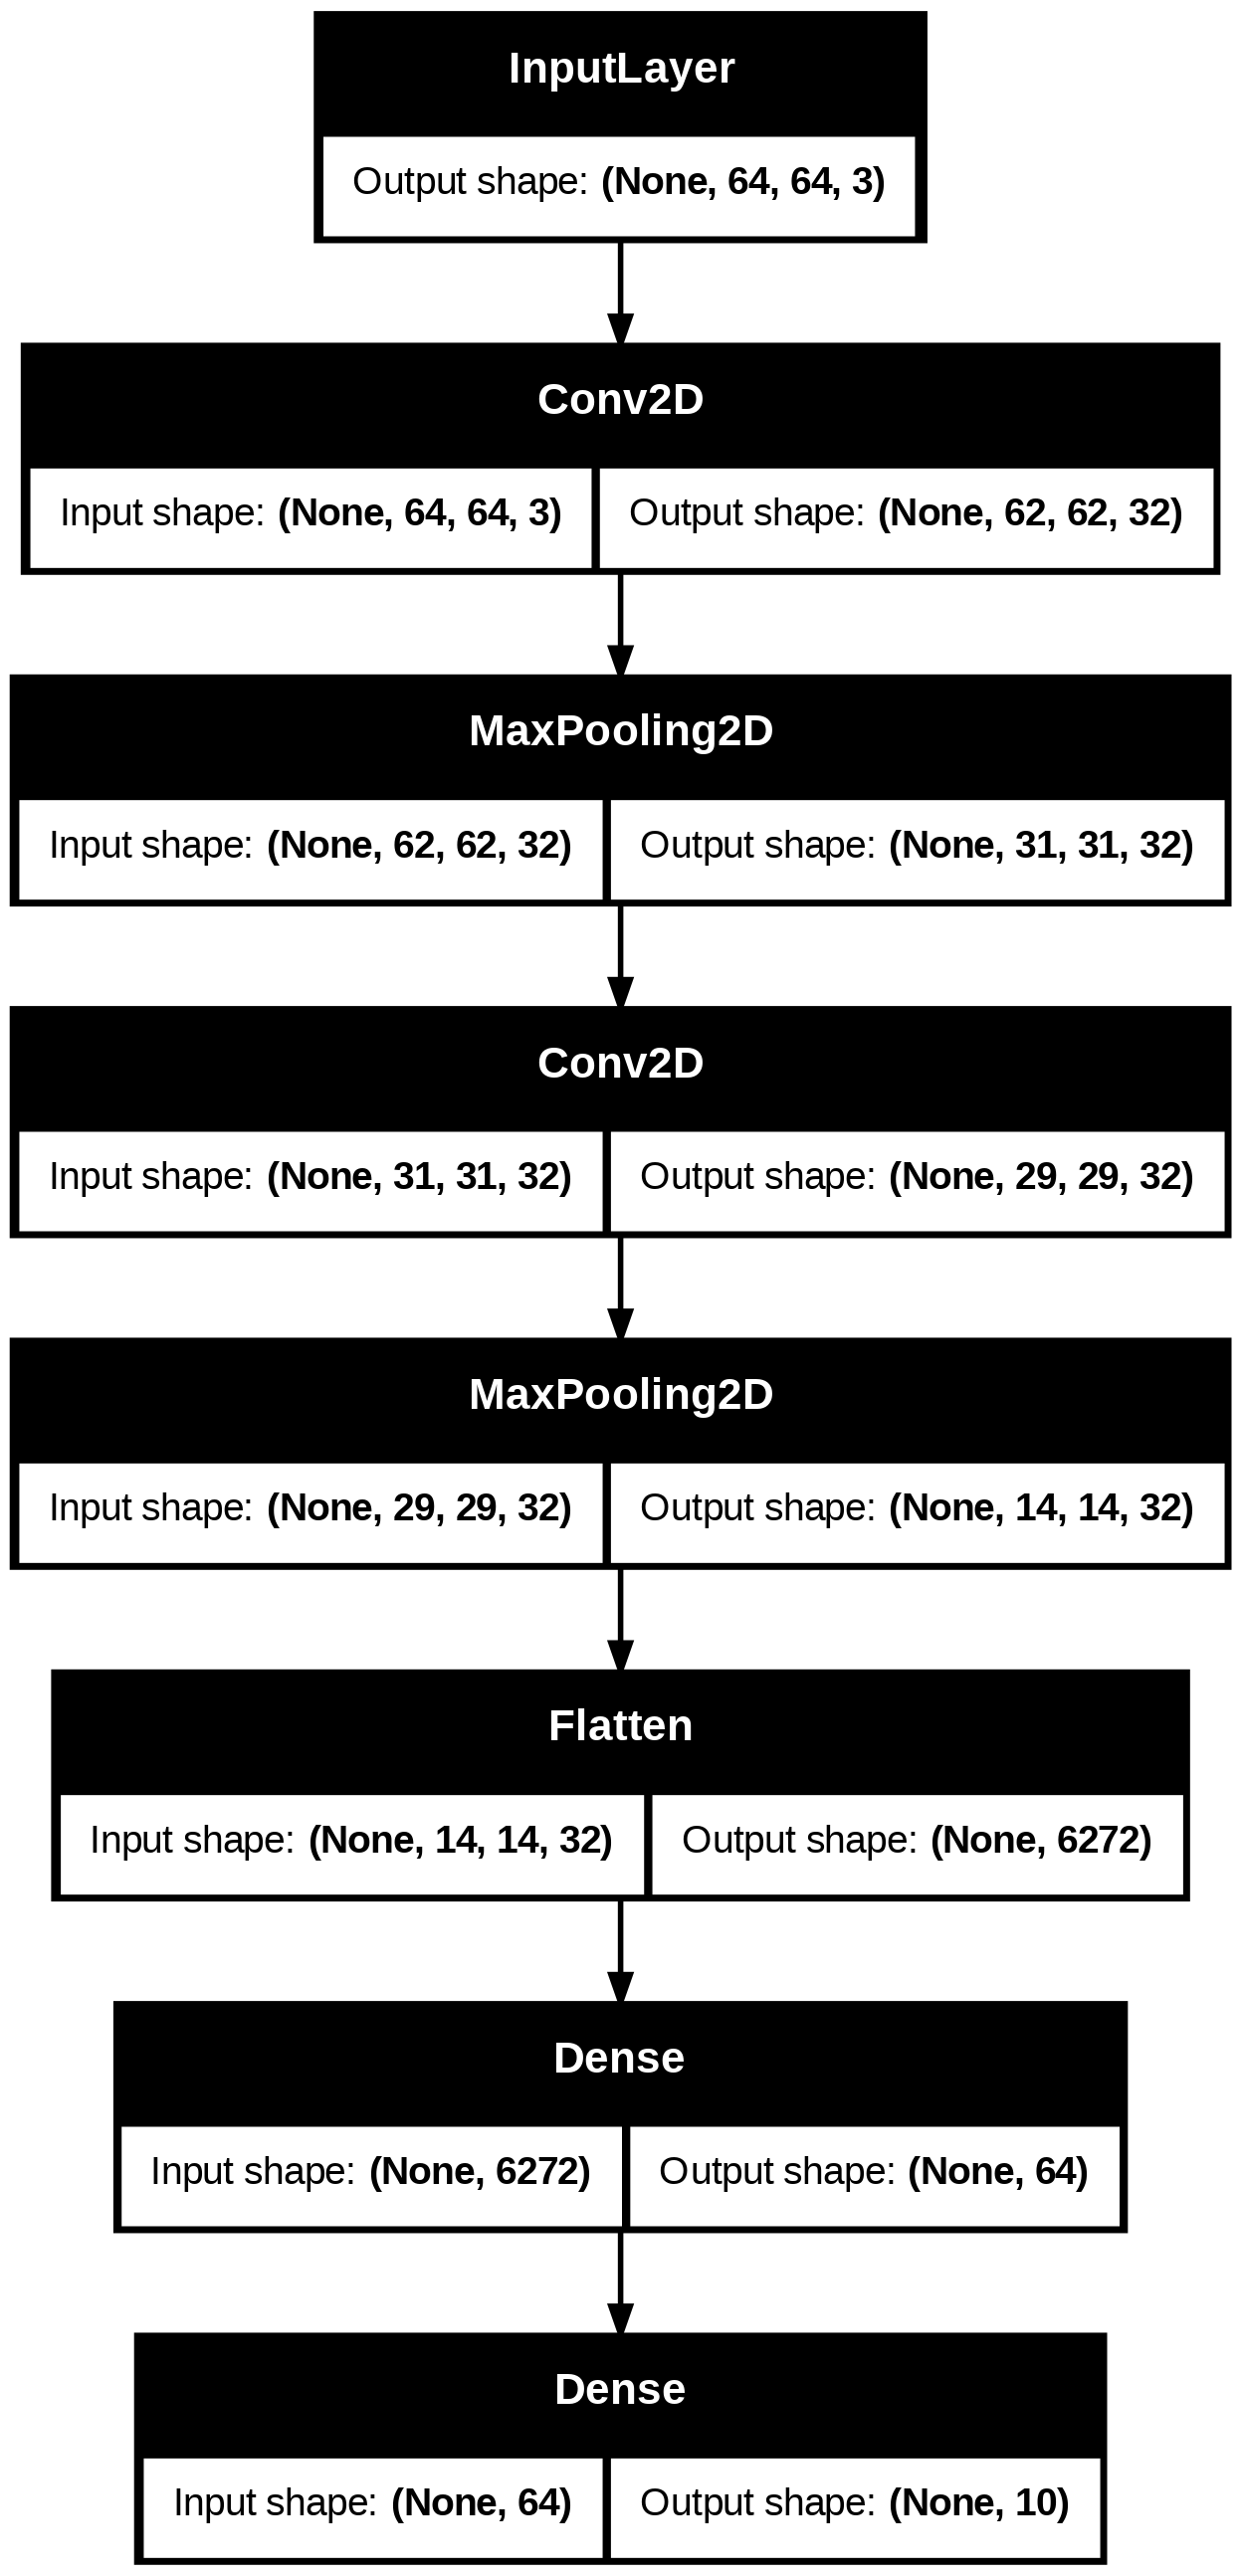

In [6]:
plot_model(model, show_shapes=True)

In [7]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras import backend as K

def create_metrics():
    @tf.function
    def f1_score(y_true, y_pred):
        tp = true_positive(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())

        return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

    @tf.function
    def specificity(y_true, y_pred):
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        return tn / (tn + fp + tf.keras.backend.epsilon())

    @tf.function
    def sensitivity(y_true, y_pred):
        tp = true_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)
        return tp / (tp + fn + tf.keras.backend.epsilon())

    @tf.function
    def mcc(y_true, y_pred):
        tp = true_positive(y_true, y_pred)
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        numerator = (tp * tn - fp * fn)
        denominator = tf.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        return numerator / (denominator + tf.keras.backend.epsilon())

    @tf.function
    def true_positive(y_true, y_pred):
        y_pred_pos, _, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_pos * y_pred_pos)

    @tf.function
    def false_positive(y_true, y_pred):
        y_pred_pos, _, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_neg * y_pred_pos)

    @tf.function
    def false_negative(y_true, y_pred):
        _, y_pred_neg, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_pos * y_pred_neg)

    @tf.function
    def true_negative(y_true, y_pred):
        _, y_pred_neg, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_neg * y_pred_neg)

    @tf.function
    def calculate_confusion_matrix(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_pred_pos = tf.round(tf.clip_by_value(y_pred, 0, 1))
        y_pred_neg = 1 - y_pred_pos
        y_pos = tf.round(tf.clip_by_value(y_true, 0, 1))
        y_neg = 1 - y_pos
        return y_pred_pos, y_pred_neg, y_pos, y_neg

    # Return individual functions directly (custom ones stay as functions)
    return (
        Precision(),
        Recall(),
        f1_score,
        specificity,
        sensitivity,
        mcc,
        AUC()
    )


In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=["accuracy", *create_metrics()]
)

In [9]:
class TimeCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.perf_counter()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.perf_counter() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

    def on_train_end(self, logs=None):
        self.total_train_time = time.perf_counter() - self.train_start_time

time_callback = TimeCallback()

In [12]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Create Concrete Function
@tf.function
def forward(x):
    return model(x)

concrete_func = forward.get_concrete_function(
    tf.TensorSpec([1, 64, 64, 3], tf.float32)
)

# Freeze graph
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph = frozen_func.graph

# Calculate FLOPs
with graph.as_default():
    run_meta = tf.compat.v1.RunMetadata()

    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

    flops = tf.compat.v1.profiler.profile(
        graph=graph,
        run_meta=run_meta,
        cmd='op',
        options=opts
    )

print(f"FLOPs : {flops.total_float_ops:,}")
print(f"GFLOPs: {flops.total_float_ops/1e9:.6f}")
print(f"Parameters: {model.count_params():,}")

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


FLOPs : 23,245,980
GFLOPs: 0.023246
Parameters: 412,266


In [ ]:
TOTAL_EPOCHS = 25

start_time = perf_counter()
history = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    validation_data=val_ds,
    callbacks=[time_callback]
)
end_time = perf_counter()

Epoch 1/25


I0000 00:00:1748107818.890691      92 service.cc:148] XLA service 0x7cfe7c00e290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748107818.891575      92 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748107819.214871      92 cuda_dnn.cc:529] Loaded cuDNN version 90300


 47/245 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4508 - auc: 0.6245 - f1_score: 0.4197 - loss: 1.6494 - mcc: 0.1747 - precision: 0.4675 - recall: 0.3810 - sensitivity: 0.3810 - specificity: 0.7785                    

I0000 00:00:1748107821.289026      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6139 - auc: 0.7777 - f1_score: 0.5775 - loss: 1.0175 - mcc: 0.4020 - precision: 0.6369 - recall: 0.5339 - sensitivity: 0.5339 - specificity: 0.8479 - val_accuracy: 0.7699 - val_auc: 0.9197 - val_f1_score: 0.7517 - val_loss: 0.5381 - val_mcc: 0.6408 - val_precision: 0.7906 - val_recall: 0.7230 - val_sensitivity: 0.7224 - val_specificity: 0.9036
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7863 - auc: 0.9332 - f1_score: 0.7744 - loss: 0.4949 - mcc: 0.6764 - precision: 0.8189 - recall: 0.7391 - sensitivity: 0.7391 - specificity: 0.9183 - val_accuracy: 0.8248 - val_auc: 0.9446 - val_f1_score: 0.8141 - val_loss: 0.4428 - val_mcc: 0.7316 - val_precision: 0.8496 - val_recall: 0.7821 - val_sensitivity: 0.7843 - val_specificity: 0.9315
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8566 - auc: 0.9613 - f1_score: 0.8499 - loss: 0.3741 - mcc: 0.7789 - precision: 0.8669 - recall: 0.8354 - sensitivity: 

In [ ]:
execution_time_parts = []
avg_time_parts = []

for unit in [(3600, 'hours'), (60, 'minutes'), (1, 'seconds'), (0.001, 'milliseconds')]:
    total_value = int(time_callback.total_train_time // unit[0])
    avg_value = int(np.mean(time_callback.epoch_times) // unit[0])

    if total_value > 0 or unit[0] == 0.001:
        execution_time_parts.append((total_value, unit[1]))
    if avg_value > 0 or unit[0] == 0.001:
        avg_time_parts.append((avg_value, unit[1]))

    time_callback.total_train_time -= total_value * unit[0]
    time_callback.epoch_times = [time - avg_value * unit[0] for time in time_callback.epoch_times]

execution_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in execution_time_parts if value > 0
])

avg_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in avg_time_parts if value > 0
])

print(f"Model training took {execution_time_string}")
print(f"Average time per epoch: {avg_time_string}")

Model training took 33 seconds, 772 milliseconds
Average time per epoch: 01 seconds, 333 milliseconds


In [ ]:
_ = model.evaluate(test_ds)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9185 - auc: 0.9795 - f1_score: 0.9162 - loss: 0.2769 - mcc: 0.8747 - precision: 0.9185 - recall: 0.9143 - sensitivity: 0.9144 - specificity: 0.9594


In [ ]:
def plot_metrics(hist, metric_name_list):
    num_metrics = len(metric_name_list)

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))

    rng = range(1, len(hist.history[metric_name_list[0]]) + 1)

    for ax, metric_n in zip(axes, metric_name_list):
        metric = hist.history[metric_n]
        v_metric = hist.history[f"val_{metric_n}"]

        ax.plot(rng, metric, label=metric_n)
        ax.plot(rng, v_metric, label=f"val_{metric_n}")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_n in ("auc", "mcc"):
            ax.set_ylabel(metric_n.upper())
            ax.set_title(metric_n.upper() + " vs Epochs")
        else:
            ax.set_ylabel(metric_n.capitalize())
            ax.set_title(metric_n.capitalize() + " vs Epochs")

        max_loss = max(max(metric), max(v_metric))
        min_loss = min(min(metric), min(v_metric))
        y_max = math.ceil(max_loss)

        if min_loss > 0 or max_loss > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_loss, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlim(1, len(metric))

    plt.tight_layout()

    plt.show()

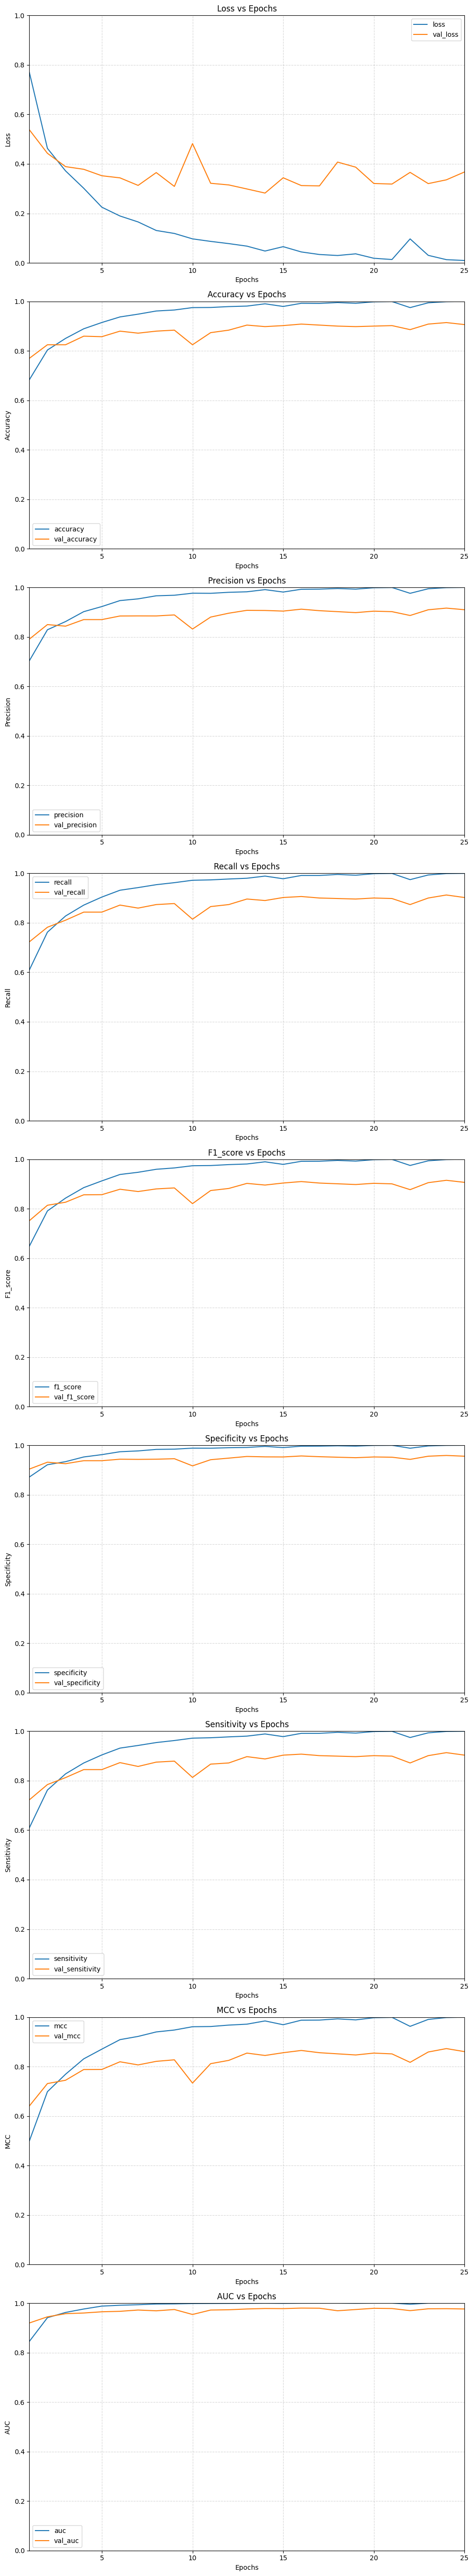

In [ ]:
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score",
                "specificity", "sensitivity", "mcc", "auc"]
plot_metrics(history, metric_names)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import tensorflow as tf

# Define class names
class_names = ['meningioma', 'glioma', 'pituitary tumor']

def generate_classification_report(model, test_dataset, target_names):
    predicted_labels = []
    true_labels = []

    for batch_data, batch_true_labels in test_dataset:
        batch_predicted_labels = model.predict(batch_data)
        batch_predicted_labels = np.argmax(batch_predicted_labels, axis=1)

        if batch_true_labels.shape[-1] > 1:
            batch_true_labels = tf.argmax(batch_true_labels, axis=1)

        predicted_labels.extend(batch_predicted_labels)
        true_labels.extend(batch_true_labels.numpy())

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=target_names,
        digits=4,
        zero_division=1
    )

    accuracy = accuracy_score(true_labels, predicted_labels)
    num_errors = np.sum(np.array(true_labels) != np.array(predicted_labels))

    print(report)
    print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy*100:6.2f}%')

    return true_labels, predicted_labels

# Run the evaluation
true_labels, predicted_labels = generate_classification_report(
    model,
    test_ds,
    target_names=class_names
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

In [ ]:
def confusion_matrix(true_labels, predicted_labels, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    np.add.at(cm, (true_labels, predicted_labels), 1)
    return cm

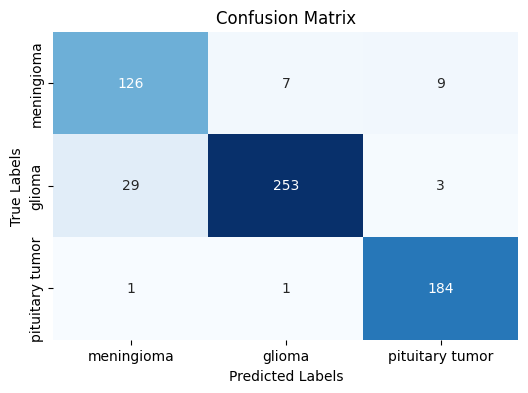

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels, 3)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()